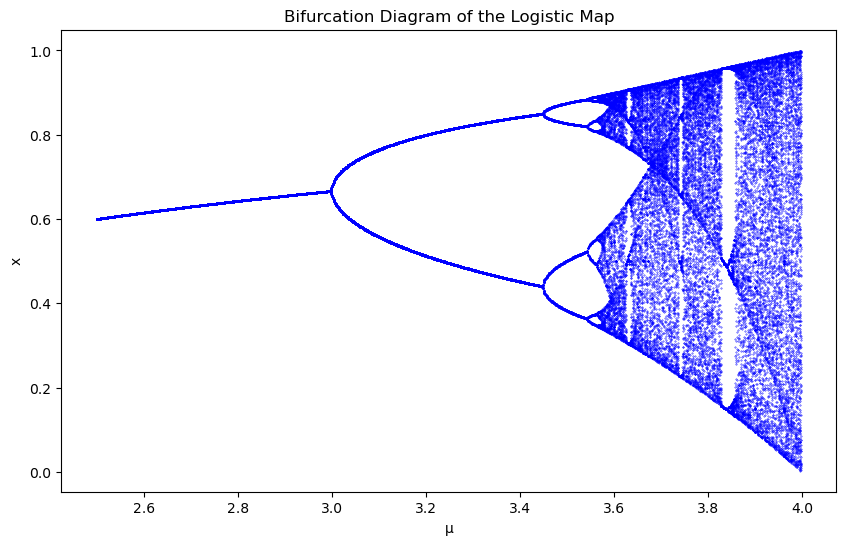

In [241]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
data = np.loadtxt("bifurcation.txt")
plt.scatter(data[:,0], data[:,1], s=0.1, color="blue")
plt.xlabel("μ")
plt.ylabel("x")
plt.title("Bifurcation Diagram of the Logistic Map")
plt.show()


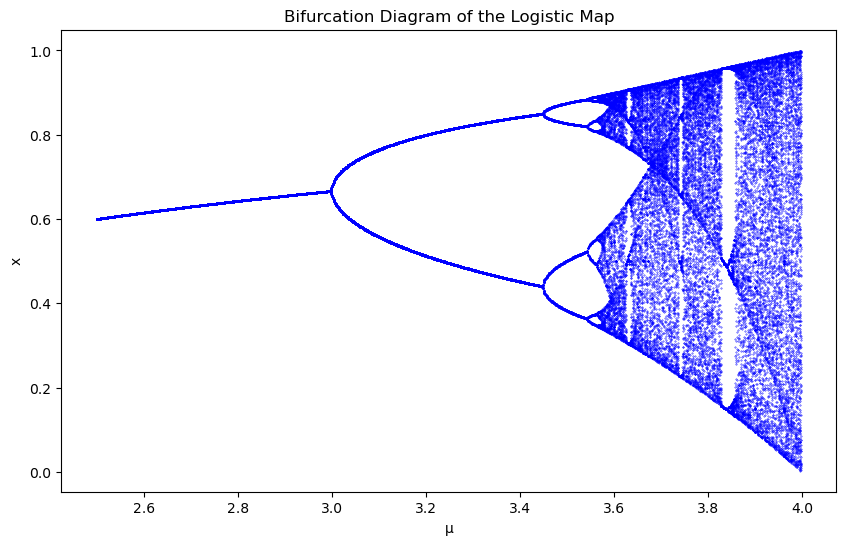

In [18]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("bifurcation.txt")
plt.figure(figsize=(10,6))
plt.scatter(data[:,0], data[:,1], s=0.1, color="blue")
plt.xlabel("μ")
plt.ylabel("x")
plt.title("Bifurcation Diagram of the Logistic Map")
plt.show()

In [20]:
import numpy as np


data = np.loadtxt("bifurcation.txt") #Loads in the data

# μ values and x values
muValues = data[:, 0]
xValues = data[:, 1]

mu_unique = np.unique(mu_values) #Find unique values
chaos = False

for mu in mu_unique:
    x_subset = xValues[muValues == mu]  # Get all x-values for this μ
    unique_x_values = len(np.unique(np.round(x_subset, 4)))  # Count distinct values
    

    if unique_x_values > 16:  # Threshhold value
        mu_critical = mu
        chaos = True
        break

if chaos:
    print(f"Estimated transition to chaos (μ_critical) ≈ {mu_critical:.3f}")



Estimated transition to chaos (μ_critical) ≈ 3.570


In [233]:
import numpy as np

# Load the bifurcation data
data = np.loadtxt("bifurcation.txt")

# Extract μ values and x values
mu_values = data[:, 0]
x_values = data[:, 1]

# Find unique μ values
mu_unique = np.unique(mu_values)

# Storage for detected bifurcation points
bifurcation_points = []
previous_unique_count = 1  # Start tracking the number of unique x-values

# Detect period-doubling transitions
for mu in mu_unique:
    x_subset = x_values[mu_values == mu]  # Get all x-values for this μ
    unique_x_count = len(np.unique(np.round(x_subset, 4)))  # Count distinct values (rounded)

    if unique_x_count >= 2 * previous_unique_count:  # Detect period doubling
        bifurcation_points.append(mu)
        previous_unique_count = unique_x_count

    # Stop if we reach chaos (arbitrary large unique count)
    if unique_x_count > 16:
        mu_critical = mu
        break

# Compute Feigenbaum ratios
feigenbaum_ratios = []
for i in range(len(bifurcation_points) - 2):
    delta_n = (bifurcation_points[i+1] - bifurcation_points[i]) / (bifurcation_points[i+2] - bifurcation_points[i+1])
    feigenbaum_ratios.append(delta_n)

# Estimate Feigenbaum constant as the last computed ratio
feigenbaum_estimate = feigenbaum_ratios[-1] if feigenbaum_ratios else None

# Print results
print(f"Estimated transition to chaos (μ_critical) ≈ {mu_critical:.3f}")
print(f"Detected bifurcation points: {bifurcation_points}")
print(f"Estimated Feigenbaum constant: {feigenbaum_estimate:.4f}" if feigenbaum_estimate else "Not enough bifurcations detected.")


Estimated transition to chaos (μ_critical) ≈ 3.570
Detected bifurcation points: [2.9935, 2.995, 2.998, 3.5695]
Estimated Feigenbaum constant: 0.0052


In [44]:
import numpy as np

def logistic_map(x, mu):
    return mu * x * (1 - x)

def find_stable_fixpoints(mu, x0, iterations=500, last=100): #Finds stable points
    x_values = [x0]
    
    for _ in range(iterations):
        x_values.append(logistic_map(x_values[-1], mu)) #Adds to the stable fixpoints

    stable_values = np.unique(np.round(x_values[-last:], 6))  # Unique values
    return stable_values

# Initial condition
x0 = 0.2

fixpoints_mu_28 = find_stable_fixpoints(2.8, x0)  # μ = 2.8 (Period-1 regime)
fixpoints_mu_35 = find_stable_fixpoints(3.5, x0)  # μ = 3.5 (Period-4 regime)

print(f"Stable fixpoints for μ = 2.8: {fixpoints_mu_28}")
print(f"Stable fixpoints for μ = 3.5: {fixpoints_mu_35}")


Stable fixpoints for μ = 2.8: [0.642857]
Stable fixpoints for μ = 3.5: [0.38282  0.500884 0.826941 0.874997]


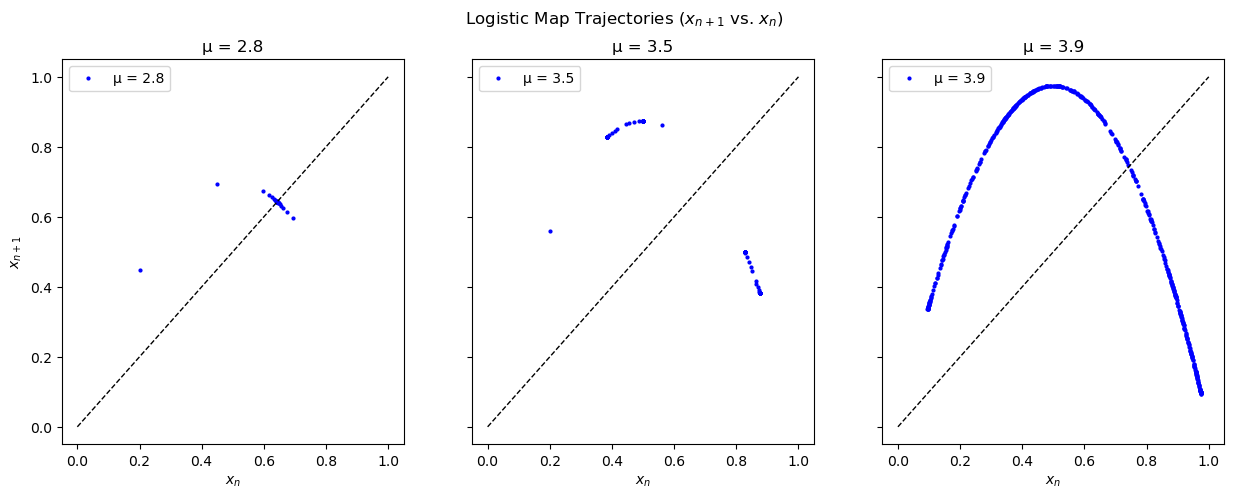

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, mu):
    return mu * x * (1 - x)

x0 = 0.2  # Initial value
iterations = 500  # Number of iterations
mu_values = [2.8, 3.5, 3.9]  # Period-1, Period-4, Chaotic

x_identity = np.linspace(0, 1, 100) #Creates the identity line

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True) #Makes 3 plots

for i, mu in enumerate(mu_values):
    x_values = [x0]

    for _ in range(iterations): #iterates through my logitic map
        x_values.append(logistic_map(x_values[-1], mu))

    x_n = np.array(x_values[:-1])
    x_np1 = np.array(x_values[1:])

    # Plot trajectory
    axes[i].plot(x_identity, x_identity, 'k--', linewidth=1)  # Identity line
    axes[i].plot(x_n, x_np1, 'o', markersize=2, color="blue", label=f'mu = {mu}')
    axes[i].set_xlabel("$x_n$")
    axes[i].set_title(f"μ = {mu}")
    axes[i].legend()

axes[0].set_ylabel("$x_{n+1}$")
plt.suptitle("Logistic Map Trajectories ($x_{n+1}$ vs. $x_n$)")
plt.show()


Intersections with the identity line (approx): [0.38288288288288286, 0.4289289289289289, 0.5010010010010011, 0.7142142142142143, 0.8273273273273274, 0.8573573573573574, 0.8753753753753755]


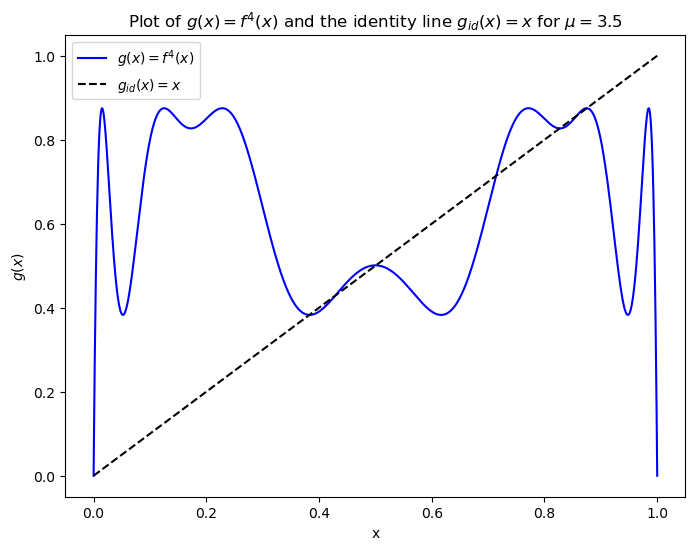

Intersection at x ≈ 0.38288 is Stable.
Intersection at x ≈ 0.42893 is Unstable.
Intersection at x ≈ 0.50100 is Stable.
Intersection at x ≈ 0.71421 is Unstable.
Intersection at x ≈ 0.82733 is Stable.
Intersection at x ≈ 0.85736 is Unstable.
Intersection at x ≈ 0.87538 is Stable.


In [46]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, mu):
    return mu * x * (1 - x)

def iterate_logistic(x, mu, N=4): #g(x) = f^4(x)
    for i in range(N):
        x = logistic_map(x, mu)
    return x

mu = 3.5
x_vals = np.linspace(0, 1, 1000)  # 1000 points between 0 and 1
g_vals = [iterate_logistic(x, mu, N=4) for x in x_vals]  # Compute g(x) = f^4(x) for 1000 points

#Plotting g(x)
plt.figure(figsize=(8, 6))
plt.plot(x_vals, g_vals, label=r'$g(x) = f^4(x)$', color='blue')
plt.plot(x_vals, x_vals, '--', label=r'$g_{id}(x) = x$', color='black')  # Identity line
plt.xlabel("x")
plt.ylabel("$g(x)$")
plt.title(r"Plot of $g(x) = f^4(x)$ and the identity line $g_{id}(x) = x$ for $\mu = 3.5$")
plt.legend()

# Finding the intersections between g(x) and identity line
intersections = []
for i in range(len(x_vals) - 1):
    if (g_vals[i] - x_vals[i]) * (g_vals[i+1] - x_vals[i+1]) < 0:  # Sign change means intersection
        intersection_x = (x_vals[i] + x_vals[i+1]) / 2
        intersections.append(intersection_x)

print(f"Intersections with the identity line (approx): {intersections}")

plt.show()

def is_stable(mu, x, N=4, epsilon=1e-5): #Stability function
    x_plus_epsilon = x + epsilon
    g_prime = (iterate_logistic(x_plus_epsilon, mu, N) - iterate_logistic(x, mu, N)) / epsilon #numerical differentiation
    return "Stable" if abs(g_prime) < 1 else "Unstable"

for intersection in intersections:
    stability = is_stable(mu, intersection)
    print(f"Intersection at x ≈ {intersection:.5f} is {stability}.")


Iteration 0: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 1: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 2: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 3: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 4: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 5: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 6: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 7: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 8: dx = 1e-15, log(dx) = -34.538776394910684
Iteration 9: dx = 1e-15, log(dx) = -34.538776394910684


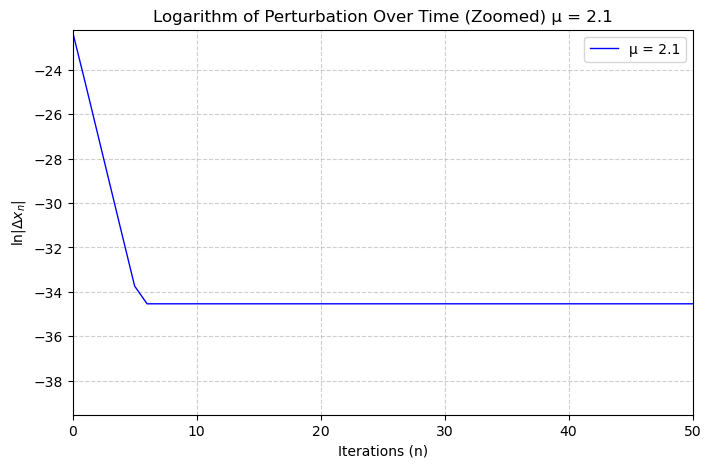

Estimated Lyapunov exponent for μ = 2.1: -2.3025


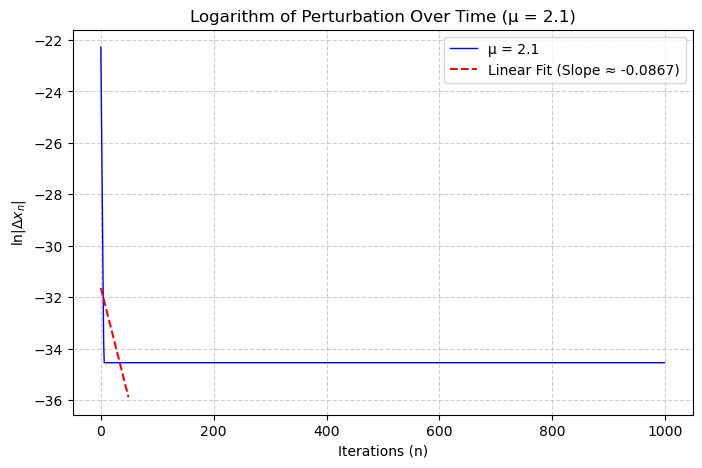

Computed Lyapunov exponent: -2.3025
Fitted slope: -0.0867


In [119]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 2.1  # Specific μ value
x0 = 0.5  # Initial condition
epsilon = 1e-5  # Small perturbation
iterations = 1000  # Total iterations

# Initialize values
x1 = x0  
x2 = x0 + epsilon  

divergence = []
sum_lyap = 0  

# Iteration loop
for i in range(iterations):
    x1 = logistic_map(x1, mu)
    x2 = logistic_map(x2, mu)

    dx = abs(x2 - x1)
    if dx < 1e-15:
        dx = 1e-15

    divergence.append(np.log(dx))
    sum_lyap += np.log(abs((mu * (1 - 2 * x1))))  

for i in range(10):  # Print first 10 iterations
    print(f"Iteration {i}: dx = {dx}, log(dx) = {np.log(dx)}")


# Compute Lyapunov exponent
lyapunov_exponent = sum_lyap / iterations

# Plot with zoomed-in view
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), divergence, label=f'μ = {mu}', color='b', linewidth=1)

# Zoom in by adjusting the y-axis limits
plt.xlim(0, 50)  # Show first 50 iterations
plt.ylim(min(divergence[:50]) - 5, max(divergence[:50]) + 0.1)


plt.xlabel("Iterations (n)")
plt.ylabel(r"$\ln |\Delta x_n|$")
plt.title(f"Logarithm of Perturbation Over Time (Zoomed) μ = {mu}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Estimated Lyapunov exponent for μ = {mu}: {lyapunov_exponent:.4f}")


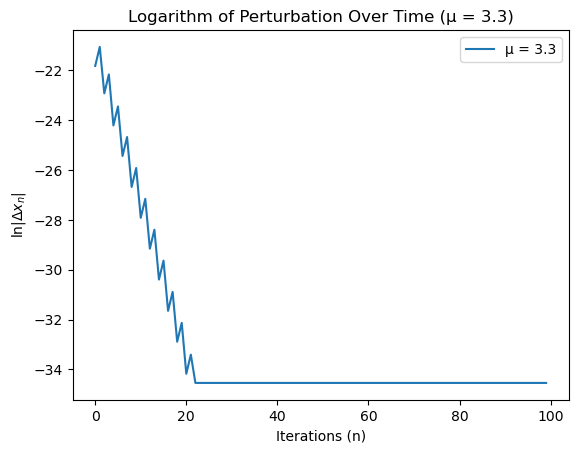

Estimated Lyapunov exponent for μ = 3.3: -0.6179


In [175]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 3.3  # Specific μ value
x0 = 0.5  # Initial condition
epsilon = 1e-5  # Small perturbation
iterations = 100  # Total iterations

# Initialize values
x1 = x0  
x2 = x0 + epsilon  

divergence = []
sum_lyap = 0  

# Iteration loop
for i in range(iterations):
    x1 = logistic_map(x1, mu)
    x2 = logistic_map(x2, mu)

    dx = abs(x2 - x1)
    if dx < 1e-15:
        dx = 1e-15

    divergence.append(np.log(dx))
    sum_lyap += np.log(abs((mu * (1 - 2 * x1))))  

# Compute Lyapunov exponent
lyapunov_exponent = sum_lyap / iterations

# Plot
plt.figure()
plt.plot(range(iterations), divergence, label=f'μ = {mu}')
plt.xlabel("Iterations (n)")
plt.ylabel(r"$\ln |\Delta x_n|$")
plt.title(f"Logarithm of Perturbation Over Time (μ = {mu})")
plt.legend()
plt.show()

print(f"Estimated Lyapunov exponent for μ = {mu}: {lyapunov_exponent:.4f}")


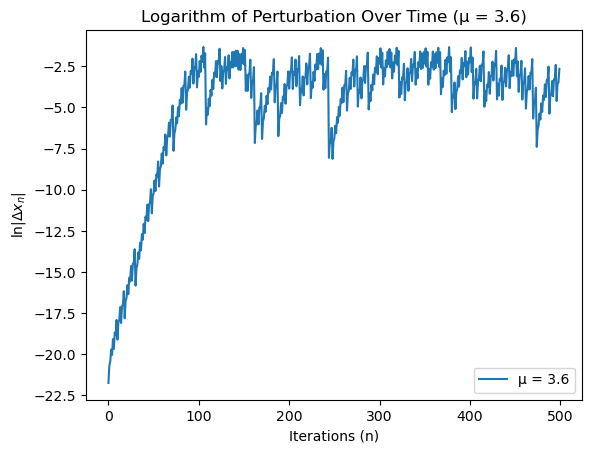

Estimated Lyapunov exponent for μ = 3.6: 0.1970


In [231]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 3.6  # Specific μ value
x0 = 0.5  # Initial condition
epsilon = 1e-5  # Small perturbation
iterations = 500  # Total iterations

# Initialize values
x1 = x0  
x2 = x0 + epsilon  

divergence = []
sum_lyap = 0  

# Iteration loop
for i in range(iterations):
    x1 = logistic_map(x1, mu)
    x2 = logistic_map(x2, mu)

    dx = abs(x2 - x1)
    if dx < 1e-30:
        dx = 1e-30

    divergence.append(np.log(dx))
    sum_lyap += np.log(abs((mu * (1 - 2 * x1))))  

# Compute Lyapunov exponent
lyapunov_exponent = sum_lyap / iterations

# Plot
plt.figure()
plt.plot(range(iterations), divergence, label=f'μ = {mu}')
plt.xlabel("Iterations (n)")
plt.ylabel(r"$\ln |\Delta x_n|$")
plt.title(f"Logarithm of Perturbation Over Time (μ = {mu})")
plt.legend()
plt.show()

print(f"Estimated Lyapunov exponent for μ = {mu}: {lyapunov_exponent:.4f}")


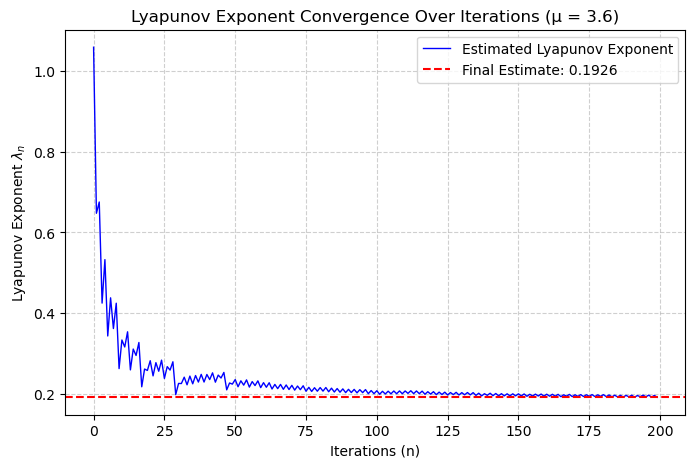

Final estimated Lyapunov exponent for μ = 3.6: 0.1926


In [165]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 3.6  # Chaotic μ value
x0 = 0.5  # Initial condition
iterations = 200  # Total iterations
num_runs = 50  # Number of different initial conditions

# Storage for Lyapunov exponent computation at each iteration
lyapunov_values = np.zeros(iterations)

# Run multiple trials with slightly different x0 values
for run in range(num_runs):
    x = x0 + (run * 1e-5)  # Slight variation in initial condition
    sum_lyap = 0  # Reset sum for each run

    for i in range(iterations):
        x = logistic_map(x, mu)
        derivative = abs(mu * (1 - 2 * x))  # Compute |f'(x)|

        if derivative < 1e-10:  # Avoid log(0)
            derivative = 1e-10

        sum_lyap += np.log(derivative)  # Accumulate sum
        lyapunov_values[i] += sum_lyap / (i + 1)  # Compute λ_n at each iteration

# Average over all runs
lyapunov_values /= num_runs

# Plot Lyapunov exponent over iterations
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), lyapunov_values, color='b', linewidth=1, label=f'Estimated Lyapunov Exponent')

plt.axhline(y=lyapunov_values[-1], color='r', linestyle='--', label=f'Final Estimate: {lyapunov_values[-1]:.4f}')

plt.xlabel("Iterations (n)")
plt.ylabel(r"Lyapunov Exponent $\lambda_n$")
plt.title(f"Lyapunov Exponent Convergence Over Iterations (μ = {mu})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print final estimated Lyapunov exponent
print(f"Final estimated Lyapunov exponent for μ = {mu}: {lyapunov_values[-1]:.4f}")


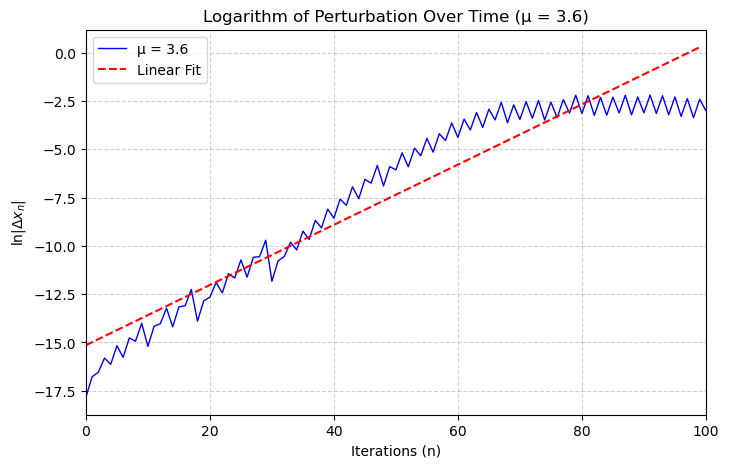

Estimated Lyapunov exponent for μ = 3.6: 0.1557


In [221]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 3.6  # Adjust for each μ value (2.1, 3.3, 3.6)
x0_base = 0.5 
epsilon = 1e-5  # Small perturbation
iterations = 1000  # Total iterations
num_runs = 50  # Number of different initial conditions

divergence_matrix = np.zeros((num_runs, iterations))

for run in range(num_runs): #Runs slightly different x values each time
    x1 = x0_base + (run * epsilon) 
    x2 = x1 + epsilon  # Perturbation

    for i in range(iterations):
        x1 = logistic_map(x1, mu)
        x2 = logistic_map(x2, mu)

        dx = abs(x2 - x1)
        if dx < 1e-30:  # Prevent log(0) issues by limiting how small the values can run
            dx = 1e-30
        
        divergence_matrix[run, i] = dx  # Store perturbation

avg_divergence = np.mean(divergence_matrix, axis=0) #Finds the average

# Take the log of the averaged perturbation
log_divergence = np.log(avg_divergence)

# Linear fitting for a line of the first couple of iterations
fit_range = 100  # Adjusted
n_values = np.arange(fit_range)
log_divergence_fit = log_divergence[:fit_range]

slope, intercept, _, _, _ = linregress(n_values, log_divergence_fit) #linear regression for line

#Plotting
plt.plot(n_values, slope * n_values + intercept, 'r--', label='Linear Fit')
plt.plot(range(iterations), log_divergence, label=f'mu = {mu}', color='b', linewidth=1)
plt.legend()
plt.xlabel("Iterations (n)")
plt.ylabel(r"$\ln |\Delta x_n|$")
plt.xlim(0,100) #Changed based on graph
plt.title(f"Logarithm of Perturbation Over Time (mu = {mu})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


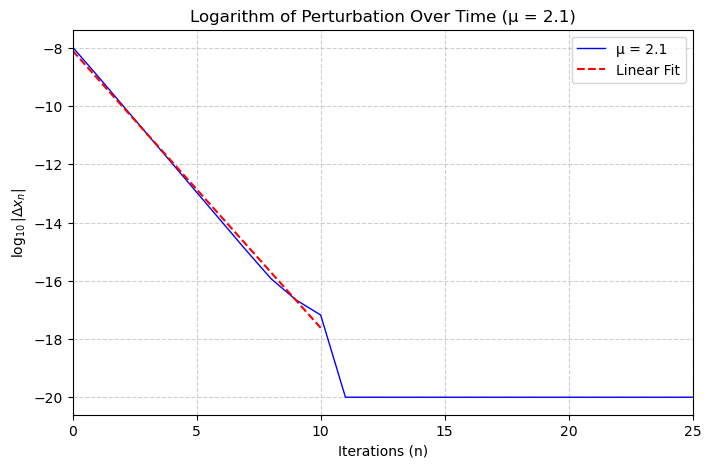

Estimated Lyapunov exponent for μ = 2.1: -0.9516


In [225]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 2.1  # Adjusted for this case
x0_base = 0.5  # Base initial condition
epsilon = 1e-5  # Larger perturbation to avoid numerical issues
iterations = 1000  # Total iterations
num_runs = 50  # Number of different initial conditions

# Storage for averaging over multiple runs
divergence_matrix = np.zeros((num_runs, iterations))

# Run multiple trials with slightly different x0 values
for run in range(num_runs):
    x1 = x0_base + (run * epsilon)  # Slightly different initial condition for each run
    x2 = x1 + epsilon  # Perturbation

    for i in range(iterations):
        x1 = logistic_map(x1, mu)
        x2 = logistic_map(x2, mu)

        dx = abs(x2 - x1)
        if dx < 1e-20:  # Prevent log(0) issues
            dx = 1e-20  # Use smaller cutoff to prevent artificial jumps
        
        divergence_matrix[run, i] = dx  # Store perturbation for this run

# Compute the average |Δx_n| over all runs
avg_divergence = np.mean(divergence_matrix, axis=0)

# Take the log of the averaged perturbation
log_divergence = np.log10(avg_divergence)  # Using log10 to avoid extreme values

# Automatically detect when numerical issues start (before it flattens)
fit_range = np.argmax(log_divergence < -18)  # Stop before artificial flattening
if fit_range < 5:  # Ensure we fit over a reasonable range
    fit_range = 10

# Perform linear regression on valid range
n_values = np.arange(fit_range)
log_divergence_fit = log_divergence[:fit_range]
slope, intercept, _, _, _ = linregress(n_values, log_divergence_fit)

# Plot log of perturbation growth
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), log_divergence, label=f'μ = {mu}', color='b', linewidth=1)

# Plot linear fit
plt.plot(n_values, slope * n_values + intercept, 'r--', label=f'Linear Fit')

plt.xlabel("Iterations (n)")
plt.ylabel(r"$\log_{10} |\Delta x_n|$")
plt.title(f"Logarithm of Perturbation Over Time (μ = {mu})")
plt.legend()
plt.xlim(0,25)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print results
print(f"Estimated Lyapunov exponent for μ = {mu}: {slope:.4f}")


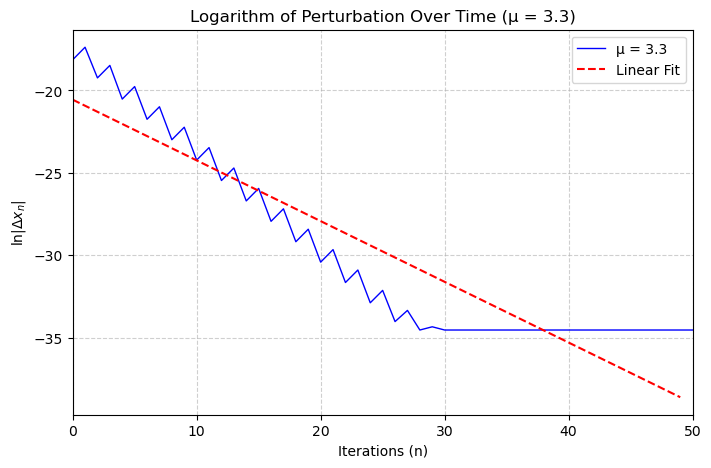

Estimated Lyapunov exponent for μ = 3.3: -0.3685


In [229]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Parameters
mu = 3.3  # Adjusted for this case
x0_base = 0.5  # Base initial condition
epsilon = 1e-5  # Small perturbation
iterations = 1000  # Total iterations
num_runs = 40  # Number of different initial conditions

# Storage for averaging over multiple runs
divergence_matrix = np.zeros((num_runs, iterations))

# Run multiple trials with slightly different x0 values
for run in range(num_runs):
    x1 = x0_base + (run * epsilon)  # Slightly different initial condition for each run
    x2 = x1 + epsilon  # Perturbation

    for i in range(iterations):
        x1 = logistic_map(x1, mu)
        x2 = logistic_map(x2, mu)

        dx = abs(x2 - x1)
        if dx < 1e-15:  # Prevent log(0) issues
            dx = 1e-15
        
        divergence_matrix[run, i] = dx  # Store perturbation for this run

# Compute the average |Δx_n| over all runs
avg_divergence = np.mean(divergence_matrix, axis=0)

# Take the log of the averaged perturbation
log_divergence = np.log(avg_divergence)

# Select the first N iterations for linear fitting
fit_range = 50  # Adjust based on where the line is clearest
n_values = np.arange(fit_range)
log_divergence_fit = log_divergence[:fit_range]

# Perform linear regression to estimate the slope
slope, intercept, _, _, _ = linregress(n_values, log_divergence_fit)

# Plot log of perturbation growth
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), log_divergence, label=f'μ = {mu}', color='b', linewidth=1)
plt.xlim(0,50)

# Plot linear fit
plt.plot(n_values, slope * n_values + intercept, 'r--', label=f'Linear Fit')

plt.xlabel("Iterations (n)")
plt.ylabel(r"$\ln |\Delta x_n|$")
plt.title(f"Logarithm of Perturbation Over Time (μ = {mu})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print results
print(f"Estimated Lyapunov exponent for μ = {mu}: {slope:.4f}")


In [227]:
# Re-run the computation since the execution state was reset

import numpy as np

# Logistic map function
def logistic_map(x, mu):
    return mu * x * (1 - x)

# Function to compute Lyapunov exponent
def compute_lyapunov(mu, x0=0.5, iterations=5000, discard=1000):
    x = x0
    lyapunov_sum = 0

    # Iterate the logistic map
    for i in range(iterations):
        x = logistic_map(x, mu)
        derivative = abs(mu * (1 - 2 * x))  # Compute |f'(x)|

        if derivative < 1e-10:  # Avoid log(0) issues
            derivative = 1e-10

        if i >= discard:  # Discard initial transient steps
            lyapunov_sum += np.log(derivative)

    # Compute Lyapunov exponent
    lyapunov_exponent = lyapunov_sum / (iterations - discard)
    return lyapunov_exponent

# Values of mu to compute
mu_values = [2.1, 3.3, 3.6]

# Compute Lyapunov exponents for each mu
lyapunov_results = {mu: compute_lyapunov(mu) for mu in mu_values}
lyapunov_results


{2.1: -2.3025850929941125, 3.3: -0.6189371780008142, 3.6: 0.18209564638014236}

In [239]:
import numpy as np

data = np.loadtxt("bifurcation.txt")

# Extract μ values and x values
muValues = data[:, 0]
xValues = data[:, 1]
mu_unique = np.unique(mu_values)

bifurcation_points = []
unique_count = 1  # Tracks the number of unique values

# Detect period-doubling transitions
for mu in mu_unique:
    x_subset = xValues[muValues == mu]  # Get all x-values for this μ
    unique_x_count = len(np.unique(np.round(x_subset, 4)))  # Count the distinct values

    if unique_x_count == 2 * unique_count: #This detects when the period doubles
        
        bifurcation_points.append(mu)
        unique_count = unique_x_count
        
    if unique_x_count > 16: #Chaotic behavior at more than 16 values
        mu_critical = mu
        break

feigenbaum_ratios = []
for i in range(len(bifurcation_points) - 2):
    changeInN = (bifurcation_points[i+1] - bifurcation_points[i]) / (bifurcation_points[i+2] - bifurcation_points[i+1]) #This computes the ratios
    feigenbaum_ratios.append(changeInN)

estimate = feigenbaum_ratios[-1] if feigenbaum_ratios else None #The last computed ratio

# Print the final Feigenbaum constant
print(f"Estimated Feigenbaum constant: {estimate:.4f}")


Estimated Feigenbaum constant: 4.3333
